# MNIST Multiclass Predictive Pipeline

## End-to-End Classification, Benchmarking, and Robustness Analysis

This project develops an end-to-end multiclass machine learning pipeline for handwritten digit classification using the MNIST (`mnist_784`) dataset.

The project covers:

1. Dataset loading and exploratory data analysis (EDA)
2. Stratified train, validation, and test splitting
3. Pixel normalization and preprocessing
4. Training and hyperparameter comparison of three different classifiers
5. Independent test-set evaluation
6. Comparative performance analysis
7. Class masking and out-of-distribution (OOD) evaluation
8. Inference on personally handwritten digits
9. Analysis of model limitations, robustness, and computational cost

The objective is not only to obtain high classification accuracy, but also to understand how different machine learning approaches behave under standard and challenging conditions.

# MNIST Multiclass Predictive Pipeline

## 0. Environment and Reproducibility

Before beginning the MNIST analysis, the computational environment is verified to ensure that the notebook is running with the intended Python interpreter and that all required libraries are available.

This project uses a dedicated Conda environment named `mnist-pipeline`. The environment contains the libraries required for data manipulation, visualization, classical machine learning, image processing, and neural-network development.

Because one of the benchmark models will be implemented using TensorFlow/Keras, TensorFlow and the available hardware devices are also verified at this stage.

The purpose of this section is reproducibility and troubleshooting. It does not constitute part of the predictive modeling experiment itself.

### 0.1 Environment Check

In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
from PIL import Image
import tensorflow as tf

print("===== SYSTEM =====")
print("Architecture:", platform.machine())

print("\n===== PYTHON =====")
print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\n===== CORE LIBRARIES =====")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Pillow:", Image.__version__)

print("\n===== TENSORFLOW =====")
print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)

print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(device)

===== SYSTEM =====
Architecture: arm64

===== PYTHON =====
Python executable:
/opt/miniconda3/envs/mnist-pipeline/bin/python

Python version:
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:38:15) [Clang 20.1.8 ]

===== CORE LIBRARIES =====
NumPy: 2.0.2
Pandas: 3.0.5
Scikit-learn: 1.9.0
Matplotlib: 3.11.1
Seaborn: 0.13.2
Pillow: 12.3.0

===== TENSORFLOW =====
TensorFlow: 2.18.1
Keras: 3.15.1

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Environment Check — Interpretation

The notebook is running in the dedicated `mnist-pipeline` Conda environment, with the required libraries successfully installed. TensorFlow/Keras is also available, and the Apple Silicon GPU is detected through the Metal backend.

The environment is ready for the MNIST experiments.

### 0.2 TensorFlow Smoke Test

In [2]:
# TensorFlow Smoke Test
# This small experiment verifies that TensorFlow can create,
# compile, and train a neural network in the project environment.

import tensorflow as tf
import numpy as np

print("===== TENSORFLOW SMOKE TEST =====")
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(device)

# Create a small synthetic binary-classification dataset.
X = np.random.rand(1000, 20).astype(np.float32)
y = np.random.randint(0, 2, size=1000)

print("\nSynthetic dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Create a small neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(20,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(2, activation="softmax")
])

# Configure the training process.
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining test model...")

history = model.fit(
    X,
    y,
    epochs=2,
    batch_size=32,
    verbose=1
)

print("\n===== SMOKE TEST COMPLETED =====")
print(
    f"Final training accuracy: "
    f"{history.history['accuracy'][-1]:.4f}"
)
print("TensorFlow neural-network training is working.")

===== TENSORFLOW SMOKE TEST =====
TensorFlow version: 2.18.1
Keras version: 3.15.1

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Synthetic dataset:
X shape: (1000, 20)
y shape: (1000,)

Training test model...
Epoch 1/2


2026-09-07 12:22:20.088753: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-09-07 12:22:20.088785: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-09-07 12:22:20.088789: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1788776540.089158 2403737 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788776540.089403 2403737 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-07 12:22:20.351090: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4520 - loss: 0.7483
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4590 - loss: 0.7389

===== SMOKE TEST COMPLETED =====
Final training accuracy: 0.4590
TensorFlow neural-network training is working.


### TensorFlow Smoke Test — Interpretation

The smoke test completed successfully, confirming that TensorFlow/Keras can train a neural network in the project environment and that GPU acceleration is available.

The synthetic dataset is used only to verify the installation; its accuracy is not relevant to the MNIST experiment.

We can now proceed to the actual dataset.

# Phase 1 — Loading and Exploratory Data Analysis (EDA)

The MNIST dataset contains 70,000 grayscale images of handwritten digits from 0 to 9. Each image has dimensions of 28 × 28 pixels.

For this project, the dataset will be represented as a matrix where each image is flattened into 784 numerical features (28 × 28). The target variable contains the corresponding digit labels.


The first step is to load the MNIST dataset and understand its structure before applying any preprocessing or training models.

This phase investigates the structure, dimensions, class distribution, pixel values, and visual representation of the dataset before preprocessing and model training.

### 1.1 Load the MNIST Dataset

MNIST is loaded with `fetch_openml()` from scikit-learn, which provides direct access to the `mnist_784` dataset and returns the images as numerical arrays that can be used directly with scikit-learn models.

The target labels are converted from strings to integers because the classification models will use the digit values (0–9) as the target classes.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

print("Loading the MNIST dataset...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto"
)

X = mnist.data
y = mnist.target.astype(np.uint8)

print("MNIST dataset loaded successfully.")

Loading the MNIST dataset...
MNIST dataset loaded successfully.


### 1.2 Dataset Structure

The next step is to verify the dimensions of the feature matrix and target vector and identify the available classes.

For MNIST, each observation should contain 784 features because each original image has 28 × 28 pixels. The target should contain one label for each image.

In [4]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nUnique classes:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

X shape: (70000, 784)
y shape: (70000,)

Number of samples: 70000
Number of features: 784

Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


### 1.2 Dataset Structure — Interpretation

The dataset contains 70,000 images represented by 784 numerical features each. The 784 features correspond to the 28 × 28 pixels of each original image after flattening the two-dimensional image into a one-dimensional vector.

There are 10 target classes, representing the digits 0 through 9, with one label for each image.

The dataset structure is therefore suitable for the multiclass classification pipeline. The next step is to check whether the digit classes are reasonably balanced.

### 1.3 Class Distribution

Before training the models, we need to check how many observations are available for each digit. This helps determine whether the dataset is reasonably balanced or whether some classes are substantially underrepresented.

In [5]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Number of samples per class:")
print(class_counts)

print("\nClass proportions:")
print((class_counts / len(y)).round(4))

Number of samples per class:
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64

Class proportions:
0    0.0986
1    0.1125
2    0.0999
3    0.1020
4    0.0975
5    0.0902
6    0.0982
7    0.1042
8    0.0975
9    0.0994
Name: count, dtype: float64


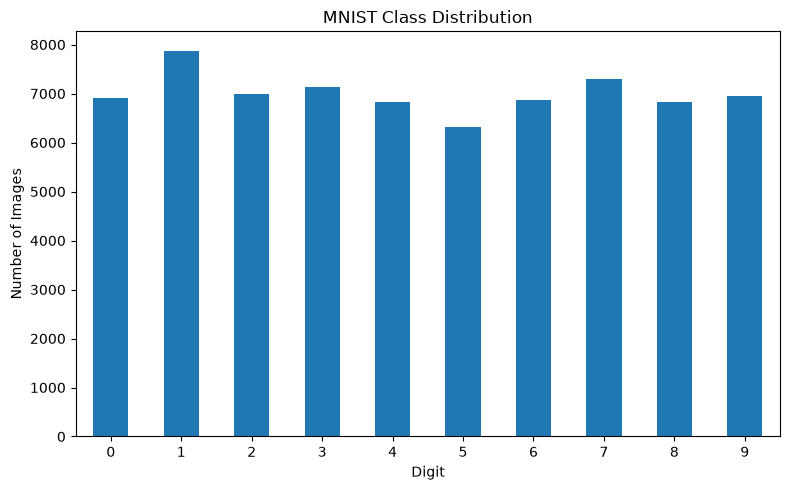

In [6]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("MNIST Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 1.3 Class Distribution — Interpretation

The 10 classes are reasonably balanced, with each digit representing approximately 9% to 11% of the dataset. Digit 5 has the fewest observations (9.02%), while digit 1 has the most (11.25%).

There is therefore no severe class imbalance that would be expected to strongly bias the classifiers toward a particular digit. Nevertheless, stratification will be used when splitting the data so that the class proportions are preserved across the different subsets.

### 1.4 Visualizing the Handwritten Digits

Although the images are stored as vectors with 784 features, each observation originally represents a 28 × 28 grayscale image.

To visualize the digits, the 784 values are reshaped back into a 28 × 28 matrix. The following grid displays 10 examples together with their original labels.

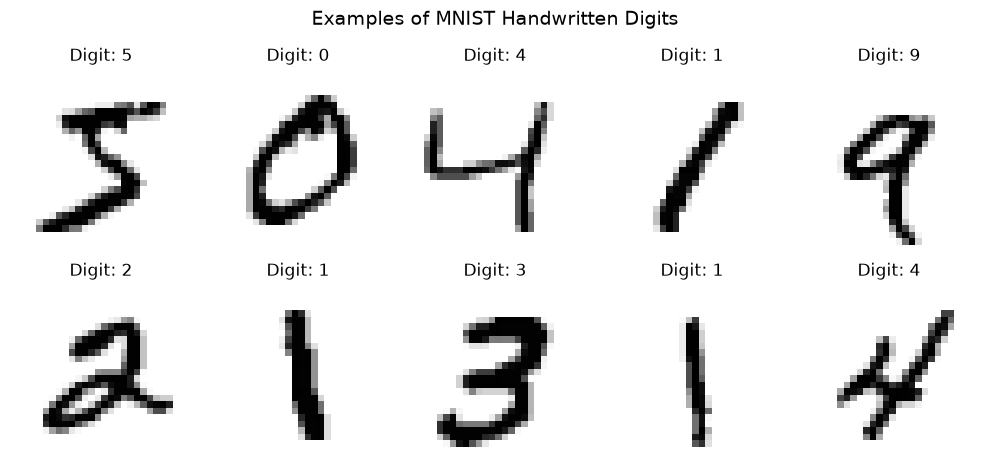

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="binary")
    ax.set_title(f"Digit: {y[i]}")
    ax.axis("off")

plt.suptitle("Examples of MNIST Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()

### 1.4 Image Representation — Interpretation

Each MNIST image has 28 × 28 pixels and is stored as a vector of 784 numerical features. Each feature represents the intensity of one pixel, with values ranging from 0 to 255.

A value close to 0 represents a very dark pixel, while a value close to 255 represents a very bright pixel. The `reshape(28, 28)` operation does not change the data; it only converts the 784-element vector back into its original two-dimensional image representation.

For the classical machine learning models used later in this project, the 784-pixel representation can be used directly as numerical input. The MLP models will also receive these 784 features as input, although the neural network can learn nonlinear relationships between them.

## Phase 2 — Data Splitting and Preprocessing

Before training the models, the dataset must be divided into independent training, validation, and test sets.

A stratified split will be used so that the proportion of the ten digit classes remains approximately consistent across all subsets. The test set will remain separate and will only be used for the final model evaluation.

The pixel intensities will then be normalized from their original range of 0–255 to the range 0–1. This provides a consistent numerical scale for the models while preserving the relative intensity information of the images.


### 2.1 Train, Validation, and Test Split

The dataset will be divided into 70% training data, 10% validation data, and 20% test data.

Stratification is applied during both splits to preserve the original class distribution in each subset.


In [8]:
from sklearn.model_selection import train_test_split

# First split: 80% temporary training/validation data and 20% test data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Temporary training/validation set:", X_train_val.shape)
print("Test set:", X_test.shape)
print("Temporary training/validation labels:", y_train_val.shape)
print("Test labels:", y_test.shape)

Temporary training/validation set: (56000, 784)
Test set: (14000, 784)
Temporary training/validation labels: (56000,)
Test labels: (14000,)


### 2.2 Training and Validation Split

The temporary training/validation set is divided again into 49,000 training images and 7,000 validation images.

The validation set will be used during model development and hyperparameter selection, while the independent test set will remain untouched until the final evaluation.


In [9]:
# Second split: 70% training and 10% validation of the original dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training set: (49000, 784)
Validation set: (7000, 784)
Test set: (14000, 784)

Training labels: (49000,)
Validation labels: (7000,)
Test labels: (14000,)


### 2.3 Verifying Stratification

The class proportions are compared across the training, validation, and test sets to confirm that stratification preserved a similar distribution of the ten digit classes.


In [10]:
split_distribution = pd.DataFrame({
    "Training": pd.Series(y_train).value_counts(normalize=True),
    "Validation": pd.Series(y_val).value_counts(normalize=True),
    "Test": pd.Series(y_test).value_counts(normalize=True)
}).sort_index()

split_distribution.round(4)

,Training,Validation,Test
0,0.0986,0.0986,0.0986
1,0.1125,0.1126,0.1125
2,0.0999,0.0999,0.0999
3,0.1020,0.1020,0.1020
4,0.0975,0.0974,0.0975
5,0.0902,0.0901,0.0902
6,0.0982,0.0983,0.0982
7,0.1042,0.1041,0.1042
8,0.0975,0.0976,0.0975
9,0.0994,0.0994,0.0994


### 2.3 Stratification — Interpretation

The class proportions are highly consistent across the training, validation, and test sets. The small differences are due only to the discrete number of samples in each subset.

This confirms that stratification successfully preserved the original MNIST class distribution and reduces the risk of introducing sampling bias through the data split.


### 2.4 Pixel Normalization

The original MNIST pixel intensities range from 0 to 255. They will be converted to floating-point values in the range 0 to 1 by dividing each pixel value by 255.

The normalized datasets will be used for model training and evaluation, while the original data will be preserved for visualization and other preprocessing steps.


In [11]:
# Normalize pixel intensities from [0, 255] to [0, 1]
X_train_scaled = X_train.astype("float32") / 255.0
X_val_scaled = X_val.astype("float32") / 255.0
X_test_scaled = X_test.astype("float32") / 255.0

print("Training pixel range:", X_train_scaled.min(), "to", X_train_scaled.max())
print("Validation pixel range:", X_val_scaled.min(), "to", X_val_scaled.max())
print("Test pixel range:", X_test_scaled.min(), "to", X_test_scaled.max())

Training pixel range: 0.0 to 1.0
Validation pixel range: 0.0 to 1.0
Test pixel range: 0.0 to 1.0


In [12]:
print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("\nTraining dtype:", X_train_scaled.dtype)
print("Validation dtype:", X_val_scaled.dtype)
print("Test dtype:", X_test_scaled.dtype)

Training shape: (49000, 784)
Validation shape: (7000, 784)
Test shape: (14000, 784)

Training dtype: float32
Validation dtype: float32
Test dtype: float32


### Phase 2 — Interpretation

The dataset was divided into 49,000 training images, 7,000 validation images, and 14,000 test images, corresponding to 70%, 10%, and 20% of the original dataset.

Stratification was applied during both splitting steps, preserving the original class distribution across the three subsets.

The pixel intensities were converted from integers in the range 0–255 to `float32` values between 0 and 1. This normalization provides a consistent numerical scale for the models and is particularly important for distance-based models such as KNN and for gradient-based neural network models.

The final shapes and data types confirm that preprocessing did not change the number of features or observations. The test set remains completely independent and will only be used for the final model evaluation in Phase 4.


## Phase 3 — Model Training and Hyperparameter Tuning

Three distinct classification approaches will be developed and compared in this phase:

1. K-Nearest Neighbors (KNN), a distance-based classical machine learning algorithm.
2. Scikit-learn MLPClassifier, a multilayer perceptron neural network.
3. TensorFlow/Keras MLP, a neural network implemented with a deep learning framework.

For each model, at least two hyperparameters will be evaluated using the training and validation sets. The independent test set will remain untouched until Phase 4.

Model performance will be evaluated using validation accuracy during development, while training and prediction time will also be recorded to support the computational cost comparison in the final analysis.


### 3.1 Model 1 — K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is used as the first predictive model because it provides a simple and interpretable classical machine learning baseline for multiclass image classification.

KNN classifies an observation according to the labels of its nearest observations in the feature space. In this project, each MNIST image is represented by 784 normalized pixel features. The model therefore operates directly on the pixel-level representation without explicitly learning spatial structures or higher-level image features.

KNN is particularly useful as a baseline because it has very little model-fitting complexity. However, this simplicity comes with an important computational trade-off: most of the computational work occurs during prediction because the algorithm must calculate distances between new observations and stored training observations.

KNN provides a useful classical machine learning baseline for this project because it approaches the classification problem differently from the two neural-network models used later.

#### KNN Default Configuration

Before tuning any hyperparameters, we establish a baseline using the standard default configuration of `KNeighborsClassifier`.

The main parameters relevant to this experiment are:

* `n_neighbors=5`: the classifier considers the five nearest training observations when predicting a class.
* `weights="uniform"`: each of the five neighbors contributes equally to the prediction.
* `metric="minkowski"`: the default distance metric.
* `p=2`: with the Minkowski metric, this corresponds to Euclidean distance.
* `algorithm="auto"`: scikit-learn automatically selects an appropriate nearest-neighbor search algorithm.
* `n_jobs=None`: computation uses the default job configuration.

For this project, we will keep the distance metric, search algorithm, and other parameters at their defaults. We will first evaluate this default configuration as a baseline and then tune two parameters: `n_neighbors` and `weights`.

This provides a clear comparison between the untuned default model and the selected tuned model.


In [13]:
# Import the KNN classifier and the accuracy metric.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import time

# Create the baseline KNN model using scikit-learn's default parameters.
knn_default = KNeighborsClassifier()

# Measure the time required to fit the model.
knn_default_start = time.perf_counter()
knn_default.fit(X_train_scaled, y_train)
knn_default_fit_time = time.perf_counter() - knn_default_start

# Measure the time required to generate validation predictions.
knn_default_pred_start = time.perf_counter()
y_val_pred_knn_default = knn_default.predict(X_val_scaled)
knn_default_prediction_time = time.perf_counter() - knn_default_pred_start

# Calculate validation accuracy for the default model.
knn_default_accuracy = accuracy_score(y_val, y_val_pred_knn_default)

print("KNN baseline (default parameters)")
print(f"n_neighbors: {knn_default.n_neighbors}")
print(f"weights: {knn_default.weights}")
print(f"metric: {knn_default.metric}")
print(f"p: {knn_default.p}")
print(f"Validation accuracy: {knn_default_accuracy:.4f}")
print(f"Fit time: {knn_default_fit_time:.4f} seconds")
print(f"Validation prediction time: {knn_default_prediction_time:.4f} seconds")

KNN baseline (default parameters)
n_neighbors: 5
weights: uniform
metric: minkowski
p: 2
Validation accuracy: 0.9694
Fit time: 0.0074 seconds
Validation prediction time: 1.2416 seconds


#### KNN Hyperparameter Tuning

After establishing the default baseline, two hyperparameters will be tuned: `n_neighbors` and `weights`.

`n_neighbors` determines how many nearby training observations are considered when assigning a class.

* Smaller values make the classifier more sensitive to local patterns. This can capture fine-grained differences between handwritten digits, but it can also make predictions more sensitive to noise or unusual observations.
* Larger values use a broader neighborhood and therefore produce smoother decisions. This can reduce sensitivity to individual observations, but excessive smoothing may remove useful local structure.

The second parameter, `weights`, determines how the neighbors contribute to the prediction.

* `uniform`: all selected neighbors contribute equally, regardless of their distance from the observation being classified.
* `distance`: closer neighbors receive greater influence than more distant neighbors.

These parameters are particularly relevant to MNIST because visually similar handwritten digits may form local clusters in the feature space. The experiment will therefore investigate whether using a smaller or larger neighborhood and whether weighting neighbors by distance improves validation performance.

The following candidate values will be tested:

* `n_neighbors`: 3, 5, and 7
* `weights`: `uniform` and `distance`

The value 5 with uniform weighting represents the default configuration and is included in the experiment so that the tuning results can be directly compared with the baseline.

Only the training and validation sets will be used during this experiment. The test set remains untouched until Phase 4.


In [14]:
# Define the KNN hyperparameter configurations to evaluate.
# The default configuration is included as a reference point.
knn_candidates = [
    {"n_neighbors": 3, "weights": "uniform"},
    {"n_neighbors": 3, "weights": "distance"},
    {"n_neighbors": 5, "weights": "uniform"},
    {"n_neighbors": 5, "weights": "distance"},
    {"n_neighbors": 7, "weights": "uniform"},
    {"n_neighbors": 7, "weights": "distance"},
]

print("KNN configurations to evaluate:")
for config in knn_candidates:
    print(config)

KNN configurations to evaluate:
{'n_neighbors': 3, 'weights': 'uniform'}
{'n_neighbors': 3, 'weights': 'distance'}
{'n_neighbors': 5, 'weights': 'uniform'}
{'n_neighbors': 5, 'weights': 'distance'}
{'n_neighbors': 7, 'weights': 'uniform'}
{'n_neighbors': 7, 'weights': 'distance'}


In [15]:
# Evaluate every KNN configuration using the training and validation sets.

knn_results = []

for config in knn_candidates:
    # Create a new KNN model for the current hyperparameter combination.
    model = KNeighborsClassifier(
        n_neighbors=config["n_neighbors"],
        weights=config["weights"]
    )

    # Measure fitting time.
    fit_start = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    fit_time = time.perf_counter() - fit_start

    # Measure validation prediction time.
    prediction_start = time.perf_counter()
    y_val_pred = model.predict(X_val_scaled)
    prediction_time = time.perf_counter() - prediction_start

    # Calculate validation accuracy.
    validation_accuracy = accuracy_score(y_val, y_val_pred)

    # Store the experiment results.
    knn_results.append({
        "n_neighbors": config["n_neighbors"],
        "weights": config["weights"],
        "validation_accuracy": validation_accuracy,
        "fit_time_seconds": fit_time,
        "validation_prediction_time_seconds": prediction_time
    })

# Convert the results into a DataFrame for easier inspection.
knn_results_df = pd.DataFrame(knn_results)

# Sort primarily by validation accuracy.
# For equal accuracy, the faster prediction configuration appears first.
knn_results_df = knn_results_df.sort_values(
    by=["validation_accuracy", "validation_prediction_time_seconds"],
    ascending=[False, True]
).reset_index(drop=True)

print("KNN hyperparameter tuning results:")
display(knn_results_df)

KNN hyperparameter tuning results:


,n_neighbors,weights,validation_accuracy,fit_time_seconds,validation_prediction_time_seconds
0,3,distance,0.972286,0.006764,1.234561
1,3,uniform,0.971857,0.018167,1.200204
2,5,distance,0.971429,0.006893,1.234915
3,7,distance,0.969857,0.006838,1.251974
4,5,uniform,0.969429,0.006509,1.222613
5,7,uniform,0.968429,0.007272,1.239283


### Interpretation

The default KNN configuration (`n_neighbors=5`, `weights="uniform"`) achieved a validation accuracy of **96.94%**.

The best configuration among the tested candidates was `n_neighbors=3` with `weights="distance"`, achieving a validation accuracy of **97.23%**. This represents an improvement of approximately **0.29 percentage points** over the default baseline.

The results show that the smaller neighborhood performed better for the tested values. Distance weighting also consistently improved validation accuracy compared with uniform weighting for the same number of neighbors.

### Technical Meaning

Using three neighbors allows KNN to make more local decisions in the feature space. Distance weighting further emphasizes the closest observations, which may be beneficial when visually similar MNIST images are located close together but more distant neighbors belong to different digit classes.

The improvement over the default configuration is relatively small, so the result should be interpreted as a validation-based improvement within the tested hyperparameter range rather than evidence that this configuration is universally optimal.

The timing results are also consistent with the nature of KNN. Fitting is very fast because the algorithm primarily stores the training observations, whereas prediction is substantially more computationally expensive because nearest neighbors must be identified for each validation observation.

### Decision

The configuration `n_neighbors=3` with `weights="distance"` will be selected as the final KNN configuration for this project because it achieved the highest validation accuracy among the tested candidates.

The test set has not been used. The final KNN model will therefore be evaluated on the independent test set only during Phase 4.


#### Final KNN Model

The validation experiment identified `n_neighbors=3` with `weights="distance"` as the best configuration among the tested candidates.

A final KNN model is now trained using this selected configuration and the complete training set. The validation set is not used for fitting the final model, and the test set remains untouched until Phase 4.

The final model's fitting time is recorded for later comparison with the other models.


In [16]:
# Train the final KNN model using the configuration selected from validation.
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

# Measure final model fitting time.
knn_final_fit_start = time.perf_counter()
knn_model.fit(X_train_scaled, y_train)
knn_final_fit_time = time.perf_counter() - knn_final_fit_start

# Evaluate the final model on the validation set.
knn_validation_pred_start = time.perf_counter()
y_val_pred_knn = knn_model.predict(X_val_scaled)
knn_validation_prediction_time = (
    time.perf_counter() - knn_validation_pred_start
)

knn_validation_accuracy = accuracy_score(y_val, y_val_pred_knn)

# Store the final KNN results for the model comparison in Phase 4.
knn_final_results = {
    "model": "KNN",
    "validation_accuracy": knn_validation_accuracy,
    "fit_time_seconds": knn_final_fit_time,
    "validation_prediction_time_seconds": knn_validation_prediction_time
}

print("Final KNN model")
print(f"n_neighbors: {knn_model.n_neighbors}")
print(f"weights: {knn_model.weights}")
print(f"Validation accuracy: {knn_validation_accuracy:.4f}")
print(f"Final fit time: {knn_final_fit_time:.4f} seconds")
print(
    f"Validation prediction time: "
    f"{knn_validation_prediction_time:.4f} seconds"
)

Final KNN model
n_neighbors: 3
weights: distance
Validation accuracy: 0.9723
Final fit time: 0.0088 seconds
Validation prediction time: 1.2441 seconds


### 3.2 Model 2 — Scikit-learn MLP

The second model is a Multilayer Perceptron (MLP) implemented with scikit-learn's `MLPClassifier`.

An MLP is a feed-forward artificial neural network that learns a set of weights from the training data. The input features are passed through one or more hidden layers, where neurons apply weighted transformations and activation functions. The network then produces an output for the ten MNIST digit classes.

For this project, the MLP provides a useful contrast with KNN. KNN is an instance-based, distance-based method that does not explicitly learn a parametric representation of the data. The MLP instead learns parameters during training and uses those learned parameters to classify new observations.

Although an MLP is a neural network, this implementation is part of scikit-learn's classical machine-learning ecosystem. It therefore provides an intermediate point between KNN and the TensorFlow/Keras neural network that will be evaluated as Model 3.

### Important Default Parameters

The default configuration in the installed scikit-learn environment was inspected directly using `MLPClassifier().get_params()`.

The most important defaults are:

* `hidden_layer_sizes=(100,)`: one hidden layer containing 100 neurons.
* `activation="relu"`: ReLU is used as the hidden-layer activation function.
* `solver="adam"`: Adam is used to optimize the network weights.
* `alpha=0.0001`: L2 regularization is applied to the model weights.
* `learning_rate_init=0.001`: the initial learning rate used by the optimizer.
* `batch_size="auto"`: the batch size is determined automatically.
* `learning_rate="constant"`: the learning-rate schedule remains constant.
* `max_iter=200`: training is allowed to run for up to 200 iterations.
* `tol=0.0001`: training can stop when the optimization improvement becomes sufficiently small.
* `early_stopping=False`: scikit-learn does not automatically reserve part of the training data for early stopping.
* `shuffle=True`: training samples are shuffled during optimization.
* `momentum=0.9`: momentum is used when applicable to the optimizer.
* `beta_1=0.9` and `beta_2=0.999`: default exponential-decay parameters used by Adam.
* `nesterovs_momentum=True`: Nesterov momentum is enabled when the selected solver supports it.

For reproducibility, `random_state=42` is set explicitly. The other model parameters remain at their default values for the baseline.

The default configuration will first be evaluated on the validation set. This establishes a baseline before any hyperparameter tuning is performed.

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import time

# Inspect the default MLPClassifier parameters in the active environment.

mlp_default = MLPClassifier(random_state=42)

print("Scikit-learn MLPClassifier default parameters")
for parameter, value in mlp_default.get_params().items():
    print(f"{parameter}: {value}")

Scikit-learn MLPClassifier default parameters
activation: relu
alpha: 0.0001
batch_size: auto
beta_1: 0.9
beta_2: 0.999
early_stopping: False
epsilon: 1e-08
hidden_layer_sizes: (100,)
learning_rate: constant
learning_rate_init: 0.001
max_fun: 15000
max_iter: 200
momentum: 0.9
n_iter_no_change: 10
nesterovs_momentum: True
power_t: 0.5
random_state: 42
shuffle: True
solver: adam
tol: 0.0001
validation_fraction: 0.1
verbose: False
warm_start: False


In [18]:
# Establish the MLP baseline using the default model configuration.
mlp_default = MLPClassifier(random_state=42)

# Measure model fitting time.
mlp_default_fit_start = time.perf_counter()
mlp_default.fit(X_train_scaled, y_train)
mlp_default_fit_time = time.perf_counter() - mlp_default_fit_start

# Measure validation prediction time.
mlp_default_pred_start = time.perf_counter()
y_val_pred_mlp_default = mlp_default.predict(X_val_scaled)
mlp_default_validation_prediction_time = (
    time.perf_counter() - mlp_default_pred_start
)

# Calculate validation accuracy.
mlp_default_validation_accuracy = accuracy_score(
    y_val,
    y_val_pred_mlp_default
)

print("Scikit-learn MLP baseline")
print(f"hidden_layer_sizes: {mlp_default.hidden_layer_sizes}")
print(f"activation: {mlp_default.activation}")
print(f"solver: {mlp_default.solver}")
print(f"alpha: {mlp_default.alpha}")
print(f"learning_rate_init: {mlp_default.learning_rate_init}")
print(f"max_iter: {mlp_default.max_iter}")
print(f"Actual iterations: {mlp_default.n_iter_}")
print(f"Validation accuracy: {mlp_default_validation_accuracy:.4f}")
print(f"Fit time: {mlp_default_fit_time:.4f} seconds")
print(
    f"Validation prediction time: "
    f"{mlp_default_validation_prediction_time:.4f} seconds"
)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Scikit-learn MLP baseline
hidden_layer_sizes: (100,)
activation: relu
solver: adam
alpha: 0.0001
learning_rate_init: 0.001
max_iter: 200
Actual iterations: 62
Validation accuracy: 0.9764
Fit time: 10.7447 seconds
Validation prediction time: 0.0029 seconds


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Interpretation

The default scikit-learn MLP achieved a validation accuracy of **97.64%** after 62 training iterations. The model therefore provides a strong baseline before hyperparameter tuning.

The fitting process took approximately **8.46 seconds**, while prediction on the validation set took only **0.008 seconds**. Compared with KNN, the MLP requires substantially more computation during training because it learns the network weights iteratively, but prediction is much faster once the model has been trained.

The model stopped after 62 iterations rather than reaching the maximum of 200 iterations, indicating that the optimization stopping criterion was reached before the maximum iteration budget was exhausted.

The baseline demonstrates the advantage of learning a parametric representation of the MNIST data. Unlike KNN, which stores the training observations and performs neighbor searches during prediction, the MLP learns weights that can be used to classify new observations efficiently.

The baseline accuracy of 97.64% is higher than the selected KNN validation accuracy of 97.23%. However, this comparison is preliminary because the models use different learning mechanisms and the MLP has not yet been tuned.


### Hyperparameter Tuning

Two hyperparameters will be tuned for the scikit-learn MLP: `hidden_layer_sizes` and `alpha`.

`hidden_layer_sizes` controls the size of the hidden layer and therefore the capacity of the network. The experiment will compare 64 and 128 neurons.

`alpha` controls the strength of L2 regularization. The experiment will compare `0.0001` and `0.001`. The default value of `0.0001` is included as a reference, while `0.001` represents stronger regularization.

The following four configurations will be evaluated:

* `(64,)`, `alpha=0.0001`
* `(64,)`, `alpha=0.001`
* `(128,)`, `alpha=0.0001`
* `(128,)`, `alpha=0.001`

All other model parameters will remain fixed at their default values, including ReLU activation, Adam optimization, an initial learning rate of `0.001`, and a maximum of 200 iterations.

Each configuration will be trained using the training set and evaluated using the validation set. The test set will not be used during tuning.

Because each configuration requires a separate neural-network training process, this experiment is expected to require considerably more computation than the KNN tuning experiment.


In [19]:
mlp_candidates = [
    {"hidden_layer_sizes": (64,), "alpha": 0.0001},
    {"hidden_layer_sizes": (64,), "alpha": 0.001},
    {"hidden_layer_sizes": (128,), "alpha": 0.0001},
    {"hidden_layer_sizes": (128,), "alpha": 0.001},
]

mlp_results = []

for config in mlp_candidates:
    model = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        alpha=config["alpha"],
        random_state=42
    )

    # Measure training time.
    fit_start = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    fit_time = time.perf_counter() - fit_start

    # Measure validation prediction time.
    prediction_start = time.perf_counter()
    y_val_pred = model.predict(X_val_scaled)
    prediction_time = time.perf_counter() - prediction_start

    # Calculate validation accuracy.
    validation_accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    mlp_results.append({
        "hidden_layer_sizes": config["hidden_layer_sizes"],
        "alpha": config["alpha"],
        "validation_accuracy": validation_accuracy,
        "fit_time_seconds": fit_time,
        "validation_prediction_time_seconds": prediction_time,
        "n_iter": model.n_iter_
    })

mlp_results_df = pd.DataFrame(mlp_results)

mlp_results_df = mlp_results_df.sort_values(
    by=["validation_accuracy", "validation_prediction_time_seconds"],
    ascending=[False, True]
).reset_index(drop=True)

print("Scikit-learn MLP hyperparameter tuning results:")
display(mlp_results_df)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/py

Scikit-learn MLP hyperparameter tuning results:


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,hidden_layer_sizes,alpha,validation_accuracy,fit_time_seconds,validation_prediction_time_seconds,n_iter
0,"(128,)",0.0010,0.978143,11.297782,0.003180,58
1,"(128,)",0.0001,0.977429,10.414071,0.002996,51
2,"(64,)",0.0010,0.971143,9.983215,0.002315,89
3,"(64,)",0.0001,0.969143,8.698853,0.002632,76


### Interpretation

The best configuration among the tested candidates was a single hidden layer with **128 neurons** and an L2 regularization strength of **`alpha=0.001`**. It achieved a validation accuracy of **97.81%**.

This represents an improvement of approximately **0.17 percentage points** over the default MLP baseline, which achieved 97.64% validation accuracy.
The results suggest that the default 100-neuron hidden layer was slightly below the most effective capacity among the tested configurations. 

The results also show a consistent effect of the hidden-layer size. The 128-neuron configurations outperformed the corresponding 64-neuron configurations. Increasing `alpha` from 0.0001 to 0.001 also improved validation accuracy for both hidden-layer sizes in this experiment.

The best configuration required approximately **8.97 seconds** for training and **0.003 seconds** for validation prediction.

Increasing the hidden layer to 128 neurons provided additional representational capacity, while the stronger L2 regularization helped control the model weights.

The improvement is relatively small, so the tuning did not fundamentally change the performance of the MLP. It produced a modest improvement over the default configuration.

### Decision

The configuration `hidden_layer_sizes=(128,)` and `alpha=0.001` will be selected as the final scikit-learn MLP configuration because it achieved the highest validation accuracy among the tested candidates.

The test set remains untouched and will only be used during Phase 4 for the final comparison of all three models.


### Final Scikit-learn MLP Model

The validation experiment identified `hidden_layer_sizes=(128,)` with `alpha=0.001` as the best configuration among the tested candidates.

A final scikit-learn MLP model is now trained using this selected configuration and the complete training set. The validation set is not used for fitting the final model, and the test set remains untouched until Phase 4.

The final model's fitting time and validation prediction time are recorded for later comparison with the other models.


In [20]:
# Train the final scikit-learn MLP model using the configuration selected from validation.
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    alpha=0.001,
    random_state=42
)

# Measure final model fitting time.
mlp_final_fit_start = time.perf_counter()
mlp_model.fit(X_train_scaled, y_train)
mlp_final_fit_time = time.perf_counter() - mlp_final_fit_start

# Evaluate the final model on the validation set.
mlp_validation_pred_start = time.perf_counter()
y_val_pred_mlp = mlp_model.predict(X_val_scaled)
mlp_validation_prediction_time = (
    time.perf_counter() - mlp_validation_pred_start
)

mlp_validation_accuracy = accuracy_score(
    y_val,
    y_val_pred_mlp
)

# Store the final MLP results for the model comparison in Phase 4.
mlp_final_results = {
    "model": "Scikit-learn MLP",
    "validation_accuracy": mlp_validation_accuracy,
    "fit_time_seconds": mlp_final_fit_time,
    "validation_prediction_time_seconds": mlp_validation_prediction_time
}

print("Final Scikit-learn MLP model")
print(f"hidden_layer_sizes: {mlp_model.hidden_layer_sizes}")
print(f"alpha: {mlp_model.alpha}")
print(f"Actual iterations: {mlp_model.n_iter_}")
print(f"Validation accuracy: {mlp_validation_accuracy:.4f}")
print(f"Final fit time: {mlp_final_fit_time:.4f} seconds")
print(
    f"Validation prediction time: "
    f"{mlp_validation_prediction_time:.4f} seconds"
)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Final Scikit-learn MLP model
hidden_layer_sizes: (128,)
alpha: 0.001
Actual iterations: 58
Validation accuracy: 0.9781
Final fit time: 11.5145 seconds
Validation prediction time: 0.0031 seconds


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 3.3 Model 3 — TensorFlow/Keras MLP

The third model is a Multilayer Perceptron (MLP) implemented using TensorFlow and Keras.

Like the scikit-learn MLP, this model is a feed-forward neural network that learns weights from the training data. It provides a second neural-network implementation using a dedicated deep-learning framework, allowing its performance and computational behaviour to be compared with both KNN and the scikit-learn MLP.

For MNIST, the network receives the 784 normalized pixel values as input and uses a fully connected hidden layer with ReLU activation, followed by an output layer with 10 units and softmax activation. The output layer produces a probability distribution across the ten digit classes.

Unlike scikit-learn's `MLPClassifier`, Keras does not define a single universal default architecture for an MLP classifier. Therefore, the baseline architecture and training configuration used in this project are explicitly defined rather than treated as framework defaults.

### Baseline Configuration

The baseline Keras MLP will use the following configuration:

* **Network architecture:** one fully connected hidden layer with 128 neurons, followed by an output layer with 10 neurons.
* **Hidden-layer activation function:** ReLU (`relu`), introducing non-linearity into the network.
* **Output-layer activation function:** softmax (`softmax`), producing a probability distribution across the ten digit classes.
* **Optimizer:** Adam, used to update the network weights during training.
* **Learning rate:** `0.001`, controlling the size of the weight updates made by the optimizer.
* **Loss function:** sparse categorical cross-entropy, appropriate for multiclass classification with integer class labels.
* **Batch size:** 128 training samples per optimization step.
* **Number of epochs:** 10 complete passes through the training data.

The baseline is deliberately kept simple so that it provides a clear reference point for the subsequent hyperparameter experiments.

The model will be trained using the training set and evaluated on the validation set after each epoch. The test set will remain untouched until Phase 4.

For reproducibility, the random seed will be fixed at `42`.



In [21]:
# Set random seeds for reproducibility.
import numpy as np
import tensorflow as tf

tf.keras.utils.set_random_seed(42)


# Build the Keras MLP with configurable hidden-layer size
# and learning rate.
def build_keras_mlp(hidden_units=128, learning_rate=0.001):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        ),
        tf.keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [22]:
# Establish the Keras MLP baseline using the project-defined configuration.
keras_baseline_model = build_keras_mlp(
    hidden_units=128,
    learning_rate=0.001
)

# Measure model fitting time.
keras_baseline_fit_start = time.perf_counter()

keras_baseline_history = keras_baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

keras_baseline_fit_time = (
    time.perf_counter() - keras_baseline_fit_start
)

# Measure validation prediction time.
keras_baseline_pred_start = time.perf_counter()

y_val_pred_proba_keras_baseline = (
    keras_baseline_model.predict(
        X_val_scaled,
        verbose=0
    )
)

keras_baseline_validation_prediction_time = (
    time.perf_counter() - keras_baseline_pred_start
)

# Convert class probabilities to predicted class labels.
y_val_pred_keras_baseline = np.argmax(
    y_val_pred_proba_keras_baseline,
    axis=1
)

# Calculate validation accuracy.
keras_baseline_validation_accuracy = accuracy_score(
    y_val,
    y_val_pred_keras_baseline
)

print("TensorFlow/Keras MLP baseline")
print("hidden_units: 128")
print("learning_rate: 0.001")
print("batch_size: 128")
print("epochs: 10")
print(
    f"Validation accuracy: "
    f"{keras_baseline_validation_accuracy:.4f}"
)
print(
    f"Fit time: "
    f"{keras_baseline_fit_time:.4f} seconds"
)
print(
    f"Validation prediction time: "
    f"{keras_baseline_validation_prediction_time:.4f} seconds"
)

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8778 - loss: 0.4343 - val_accuracy: 0.9156 - val_loss: 0.3051
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9181 - loss: 0.2946 - val_accuracy: 0.9189 - val_loss: 0.2944
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9221 - loss: 0.2821 - val_accuracy: 0.9211 - val_loss: 0.2910
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9237 - loss: 0.2767 - val_accuracy: 0.9223 - val_loss: 0.2907
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9244 - loss: 0.2741 - val_accuracy: 0.9220 - val_loss: 0.2925
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9248 - loss: 0.2726 - val_accuracy: 0.9213 - val_loss: 0.2955
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9251 - loss: 0.2719 - val_accuracy: 0.9207 - val_loss: 0.2979
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9251 - loss: 0.2717 - val_accuracy: 0.

### Interpretation

The project-defined TensorFlow/Keras MLP baseline achieved a validation accuracy of **92.00%** after 10 training epochs. Validation accuracy increased during the first four epochs and reached a maximum of **92.23% at epoch 4**, after which it gradually declined to 92.00%.

The model required approximately **21.88 seconds** to train and **0.280 seconds** to generate predictions for the validation set. This is substantially more computation than the scikit-learn MLP baseline, which achieved higher validation accuracy with shorter training and prediction times.

The increase in validation loss after approximately the fourth epoch, together with the decline in validation accuracy, suggests that the baseline configuration begins to overfit during training.

The baseline demonstrates that using a dedicated deep-learning framework does not automatically result in higher performance. With the current architecture and training configuration, the Keras MLP performs below both the KNN and scikit-learn MLP models.

The result also shows that the training configuration is important. The model uses a single hidden layer with 128 neurons and an Adam learning rate of `0.001`, but the fixed 10-epoch training schedule does not prevent the validation performance from declining after the early epochs.

The baseline therefore provides a useful reference point for investigating whether changes to the network capacity and learning rate can improve validation performance.

### Decision

The project-defined baseline will be retained as the reference configuration for TensorFlow/Keras hyperparameter tuning.

The next experiment will vary hyperparameters while keeping the remaining training configuration fixed.

### Hyperparameter Tuning

Two hyperparameters will be tuned for the TensorFlow/Keras MLP: **hidden-layer size** and **learning rate**.

**Hidden-layer size** controls the number of neurons in the hidden layer and therefore the representational capacity of the network. The baseline uses 128 neurons. To assess whether the baseline provides an appropriate level of capacity, the experiment will compare a smaller configuration with 64 neurons and a larger configuration with 256 neurons.

**Learning rate** controls the size of the weight updates performed by the Adam optimizer during training. The baseline uses a learning rate of `0.001`. A smaller value of `0.0005` will also be tested to determine whether more conservative updates improve validation performance.

These two hyperparameters were selected because they affect different aspects of neural-network learning: hidden-layer size changes the model's capacity, while learning rate affects the optimization process.

The following four configurations will be evaluated:

* 64 hidden units, `learning_rate=0.001`
* 64 hidden units, `learning_rate=0.0005`
* 256 hidden units, `learning_rate=0.001`
* 256 hidden units, `learning_rate=0.0005`

The baseline configuration of 128 hidden units and a learning rate of `0.001` is not repeated in this tuning grid because it has already been evaluated separately as the baseline.

The number of epochs will remain fixed at 10 and the batch size at 128. The optimizer, activation functions, loss function, network structure, and random seed will otherwise remain unchanged.

The earlier baseline experiment showed that validation accuracy peaked around epoch 4 before declining. This suggests that training duration or early stopping could also be investigated in a separate experiment. However, these parameters are kept fixed here so that the present experiment isolates the effects of hidden-layer size and learning rate.

Each configuration will be trained using the training set and evaluated using the validation set. The test set will not be used during tuning.

Because each configuration requires a separate neural-network training process, this experiment is expected to require substantially more computation than the KNN tuning experiment.


In [23]:
# Define the Keras MLP hyperparameter configurations to evaluate.
keras_candidates = [
    {"hidden_units": 64, "learning_rate": 0.001},
    {"hidden_units": 64, "learning_rate": 0.0005},
    {"hidden_units": 256, "learning_rate": 0.001},
    {"hidden_units": 256, "learning_rate": 0.0005},
]

keras_results = []

for config in keras_candidates:
    # Reset the TensorFlow state and random seed for each configuration.
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    # Build the Keras MLP with the current hyperparameters.
    model = build_keras_mlp(
        hidden_units=config["hidden_units"],
        learning_rate=config["learning_rate"]
    )

    # Measure training time.
    fit_start = time.perf_counter()

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=10,
        batch_size=128,
        verbose=0
    )

    fit_time = time.perf_counter() - fit_start

    # Measure validation prediction time.
    prediction_start = time.perf_counter()

    y_val_pred_proba = model.predict(
        X_val_scaled,
        verbose=0
    )

    prediction_time = time.perf_counter() - prediction_start

    # Convert class probabilities to predicted class labels.
    y_val_pred = np.argmax(
        y_val_pred_proba,
        axis=1
    )

    # Calculate validation accuracy.
    validation_accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    # Store the tuning results.
    keras_results.append({
        "hidden_units": config["hidden_units"],
        "learning_rate": config["learning_rate"],
        "validation_accuracy": validation_accuracy,
        "fit_time_seconds": fit_time,
        "validation_prediction_time_seconds": prediction_time
    })

keras_results_df = pd.DataFrame(keras_results)

keras_results_df = keras_results_df.sort_values(
    by=["validation_accuracy", "validation_prediction_time_seconds"],
    ascending=[False, True]
).reset_index(drop=True)

print("TensorFlow/Keras MLP hyperparameter tuning results:")
display(keras_results_df)

TensorFlow/Keras MLP hyperparameter tuning results:


,hidden_units,learning_rate,validation_accuracy,fit_time_seconds,validation_prediction_time_seconds
0,64,0.0005,0.923571,20.427462,0.251379
1,256,0.0005,0.921857,20.841026,0.248796
2,64,0.0010,0.921714,20.742850,0.260253
3,256,0.0010,0.913857,20.777426,0.289794


### Interpretation

The best configuration among the tested TensorFlow/Keras MLP candidates was a hidden layer with **64 neurons** and a learning rate of **`0.0005`**. It achieved a validation accuracy of **92.36%**.

Compared with the project-defined Keras baseline, which used 128 hidden neurons and a learning rate of `0.001` and achieved **92.00%** validation accuracy, the selected configuration improved validation accuracy by **0.36 percentage points**.

The results show a consistent advantage for the smaller hidden layer in this experiment. With a learning rate of `0.001`, the 64-neuron model achieved 92.17% validation accuracy, compared with 91.39% for the 256-neuron model. With a learning rate of `0.0005`, the 64-neuron model achieved 92.36%, compared with 92.19% for the 256-neuron model.

The lower learning rate also improved validation accuracy for both network sizes. For 64 neurons, reducing the learning rate from `0.001` to `0.0005` increased validation accuracy from 92.17% to 92.36%. For 256 neurons, the improvement was from 91.39% to 92.19%.

These results suggest that increasing the hidden-layer size from the baseline value of 128 to 256 neurons did not improve validation performance. Instead, the smaller 64-neuron configuration performed best among the tested candidates. Under the fixed 10-epoch training schedule, the lower learning rate also produced better validation performance, suggesting that more conservative weight updates were more effective for the configurations tested.

The improvement over the baseline is relatively small, indicating that the hyperparameter tuning produced an incremental rather than fundamental improvement in Keras MLP performance.

Training times were similar across all four configurations, ranging from approximately **20.33 to 20.93 seconds**, while validation prediction times ranged from approximately **0.25 to 0.26 seconds**.

The earlier baseline validation curve showed that validation accuracy peaked around epoch 4 before declining, while validation loss increased after this point. This indicates that the fixed 10-epoch training duration may not be optimal and that training duration or early stopping could affect validation performance.

Therefore, a **separate training-duration experiment will be conducted before the final Keras model is selected**. The selected hidden-layer size and learning rate (64 hidden units and `0.0005`) will be kept fixed while the effect of training duration and early stopping is investigated. This additional experiment will determine whether stopping training earlier can improve validation performance and will provide the basis for the final Keras training configuration.

### Decision

The configuration with **64 hidden units** and **`learning_rate=0.0005`** is selected as the **best configuration from the current hyperparameter experiment**, because it achieved the highest validation accuracy among the tested candidates.

However, it is **not yet considered the final TensorFlow/Keras model**. The training-duration/early-stopping experiment will be performed next using this configuration.

The test set remains untouched and will only be used during Phase 4 for the final evaluation and comparison of all three models.

In [24]:
# Reset the TensorFlow state and random seed for reproducibility.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Build the Keras MLP using the best configuration from the
# hidden-layer size and learning-rate experiment.
keras_training_duration_model = build_keras_mlp(
    hidden_units=64,
    learning_rate=0.0005
)

# Measure training time.
keras_training_duration_fit_start = time.perf_counter()

keras_training_duration_history = (
    keras_training_duration_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=15,
        batch_size=128,
        verbose=1
    )
)

keras_training_duration_fit_time = (
    time.perf_counter() - keras_training_duration_fit_start
)

# Extract the training history.
keras_training_duration_history_df = pd.DataFrame(
    keras_training_duration_history.history
)

# Add the epoch number for easier inspection.
keras_training_duration_history_df.insert(
    0,
    "epoch",
    range(1, len(keras_training_duration_history_df) + 1)
)

# Identify the epoch with the highest validation accuracy.
best_epoch = (
    keras_training_duration_history_df[
        "val_accuracy"
    ].idxmax()
)

best_epoch_number = int(
    keras_training_duration_history_df.loc[
        best_epoch,
        "epoch"
    ]
)

best_epoch_validation_accuracy = (
    keras_training_duration_history_df.loc[
        best_epoch,
        "val_accuracy"
    ]
)

print("Keras training-duration experiment")
print("hidden_units: 64")
print("learning_rate: 0.0005")
print("batch_size: 128")
print("maximum epochs: 15")
print(
    f"Best epoch: "
    f"{best_epoch_number}"
)
print(
    f"Best validation accuracy: "
    f"{best_epoch_validation_accuracy:.4f}"
)
print(
    f"Total fit time: "
    f"{keras_training_duration_fit_time:.4f} seconds"
)

display(keras_training_duration_history_df)

Epoch 1/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8358 - loss: 0.6206 - val_accuracy: 0.9064 - val_loss: 0.3474
Epoch 2/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9113 - loss: 0.3201 - val_accuracy: 0.9151 - val_loss: 0.3074
Epoch 3/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9183 - loss: 0.2935 - val_accuracy: 0.9186 - val_loss: 0.2961
Epoch 4/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9221 - loss: 0.2814 - val_accuracy: 0.9214 - val_loss: 0.2909
Epoch 5/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9241 - loss: 0.2739 - val_accuracy: 0.9227 - val_loss: 0.2883
Epoch 6/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9257 - loss: 0.2688 - val_accuracy: 0.9229 - val_loss: 0.2874
Epoch 7/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9268 - loss: 0.2649 - val_accuracy: 0.9224 - val_loss: 0.2868
Epoch 8/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9279 - loss: 0.2619 - val_accuracy: 0.

,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.835755,0.620557,0.906429,0.347417
1,2,0.911265,0.320068,0.915143,0.307386
2,3,0.918327,0.293520,0.918571,0.296130
3,4,0.922122,0.281354,0.921429,0.290890
4,5,0.924102,0.273866,0.922714,0.288298
5,6,0.925694,0.268765,0.922857,0.287391
6,7,0.926755,0.264913,0.922429,0.286818
7,8,0.927918,0.261869,0.923714,0.286714
8,9,0.928775,0.259409,0.924000,0.286556
9,10,0.929510,0.257404,0.923571,0.286676


### Interpretation

The training-duration experiment evaluated the selected Keras configuration of **64 hidden units** and **`learning_rate=0.0005`** for up to 15 epochs. Validation accuracy increased from 90.64% at epoch 1 to **92.44% at epoch 15**, which was the highest validation accuracy observed during the experiment.

The validation accuracy did not peak around epoch 4 for this configuration. Instead, it continued to improve gradually throughout training, with some small fluctuations between epochs. Validation accuracy reached 92.37% at epoch 8, 92.43% at epochs 11, 13, and 14, and 92.44% at epoch 15.

Validation loss decreased substantially during the first several epochs, reaching approximately 0.2866 around epoch 9, and then remained relatively stable before increasing slightly toward epoch 15. At the same time, training accuracy continued to increase, reaching 93.14% by epoch 15. This indicates some divergence between training and validation performance, but the continued improvement in validation accuracy does not provide clear evidence that training should have been stopped earlier.

This result also shows why training duration should be evaluated using the selected model configuration rather than inferred solely from the original baseline. The original baseline showed a decline in validation accuracy after approximately epoch 4, whereas the selected 64-neuron, `0.0005` learning-rate configuration continued to improve beyond that point.

The total training time for 15 epochs was approximately **32.27 seconds**. The experiment therefore indicates that additional training beyond 10 epochs can provide a small improvement in validation accuracy for the selected configuration.

The improvement from the previously selected 10-epoch configuration (92.36%) to 15 epochs (92.44%) is relatively small, at **0.08 percentage points**. Therefore, the benefit of extending training is incremental rather than substantial.

### Decision

The training-duration experiment identified **15 epochs** as the best training duration among the epochs evaluated in this experiment, as it achieved the highest observed validation accuracy of **92.44%**.

The final TensorFlow/Keras configuration will therefore use:

* **Hidden units:** 64
* **Learning rate:** `0.0005`
* **Batch size:** 128
* **Epochs:** 15

Early stopping will not be introduced at this stage because validation accuracy continued to improve through the final epoch of the experiment. The current evidence therefore does not establish an earlier stopping point that would improve the selected validation metric.

The test set remains untouched and will only be used during **Phase 4** for the final evaluation and comparison of all three models.


### Final TensorFlow/Keras MLP Model

The validation experiments selected a TensorFlow/Keras MLP with **64 hidden units** and a learning rate of **`0.0005`**. A subsequent training-duration experiment showed that validation accuracy continued to improve through 15 epochs, reaching **92.44%**, the highest validation accuracy observed during the tested training period.

The final TensorFlow/Keras MLP will therefore use the following configuration:

* **Hidden units:** 64
* **Learning rate:** `0.0005`
* **Batch size:** 128
* **Epochs:** 15
* **Optimizer:** Adam
* **Hidden-layer activation:** ReLU
* **Output activation:** softmax
* **Loss function:** sparse categorical cross-entropy

The final model is trained using the complete training set with the selected configuration. The validation set is then used separately to evaluate the final model and record its validation accuracy and prediction time.

The test set remains completely untouched and will only be used in **Phase 4** for the final evaluation and comparison of the three models.


In [25]:
# Reset the TensorFlow state and random seed for reproducibility.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Build the final TensorFlow/Keras MLP using the configuration
# selected from the validation experiments.
keras_model = build_keras_mlp(
    hidden_units=64,
    learning_rate=0.0005
)

# Measure final model fitting time.
keras_final_fit_start = time.perf_counter()

keras_model.fit(
    X_train_scaled,
    y_train,
    epochs=15,
    batch_size=128,
    verbose=0
)

keras_final_fit_time = (
    time.perf_counter() - keras_final_fit_start
)

# Evaluate the final model on the validation set.
keras_validation_pred_start = time.perf_counter()

y_val_pred_proba_keras = keras_model.predict(
    X_val_scaled,
    verbose=0
)

keras_validation_prediction_time = (
    time.perf_counter() - keras_validation_pred_start
)

# Convert class probabilities to predicted class labels.
y_val_pred_keras = np.argmax(
    y_val_pred_proba_keras,
    axis=1
)

# Calculate validation accuracy.
keras_validation_accuracy = accuracy_score(
    y_val,
    y_val_pred_keras
)

# Store the final Keras results for the model comparison in Phase 4.
keras_final_results = {
    "model": "TensorFlow/Keras MLP",
    "validation_accuracy": keras_validation_accuracy,
    "fit_time_seconds": keras_final_fit_time,
    "validation_prediction_time_seconds": keras_validation_prediction_time
}

print("Final TensorFlow/Keras MLP model")
print(f"hidden_units: {keras_model.layers[0].units}")
print(
    f"learning_rate: "
    f"{keras_model.optimizer.learning_rate.numpy():.4f}"
)
print("epochs: 15")
print("batch_size: 128")
print(f"Validation accuracy: {keras_validation_accuracy:.4f}")
print(f"Final fit time: {keras_final_fit_time:.4f} seconds")
print(
    f"Validation prediction time: "
    f"{keras_validation_prediction_time:.4f} seconds"
)

Final TensorFlow/Keras MLP model
hidden_units: 64
learning_rate: 0.0005
epochs: 15
batch_size: 128
Validation accuracy: 0.9244
Final fit time: 28.2895 seconds
Validation prediction time: 0.2538 seconds


### 3.4 Final Model Comparison

The three final models selected through validation experiments provide different approaches to MNIST classification. The scikit-learn MLP achieved the highest validation accuracy among the tested final configurations, while KNN provided strong performance with very low fitting cost. The TensorFlow/Keras MLP achieved lower validation accuracy but represents a separate deep-learning implementation.

The final comparison of model suitability will be completed in **Phase 4**, using the untouched test set together with additional classification metrics and error analysis.


In [26]:
# Combine the final validation results from all three models.
final_model_comparison = pd.DataFrame([
    knn_final_results,
    mlp_final_results,
    keras_final_results
])

# Display the main validation results.
display(
    final_model_comparison[
        [
            "model",
            "validation_accuracy",
            "fit_time_seconds",
            "validation_prediction_time_seconds"
        ]
    ].round(4)
)

,model,validation_accuracy,fit_time_seconds,validation_prediction_time_seconds
0,KNN,0.9723,0.0088,1.2441
1,Scikit-learn MLP,0.9781,11.5145,0.0031
2,TensorFlow/Keras MLP,0.9244,28.2895,0.2538
